In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
module_path = os.path.abspath(os.path.join('../')) # or the path to your source code
sys.path.insert(0, module_path)

In [2]:
from analyzer.main import PatchTrack
from analyzer import common
from analyzer import dataDict
try:
    import magic
except ImportError as err:
    print (err)
    sys.exit(-1)

In [3]:

# read tokens from list
token_file = '../tokens.txt'

token_list = []
with open(token_file, 'r') as f:
    for line in f.readlines():
        token_list.append(line.strip('\n'))

# manually add in notebook
# token_list = ["nadHJok13mdkaamda", "ajd1819kdamda","..."]

lenTokens = len(token_list)

Create a magic cookie. This is needed during classification

In [4]:
common.verbose = True
try:
    common.magic_cookie = magic.open(magic.MAGIC_MIME)
    common.magic_cookie.load()
except AttributeError:
    common.magic_cookie = magic.Magic(mime=True, uncompress=True)
common.verbose_print('[-] initialized magic cookie\n')

In [5]:
data = (token_list)

In [6]:
experiment = PatchTrack(data)

In [7]:

print(len(dataDict.pr_project_pair.values()))

183



Starting classification for GitHub, - , ChatGPT...
Classification finished.
Classification Runtime: 122.28360509872437

Bar plot of the patch classifications for GitHub -> ChatGPT


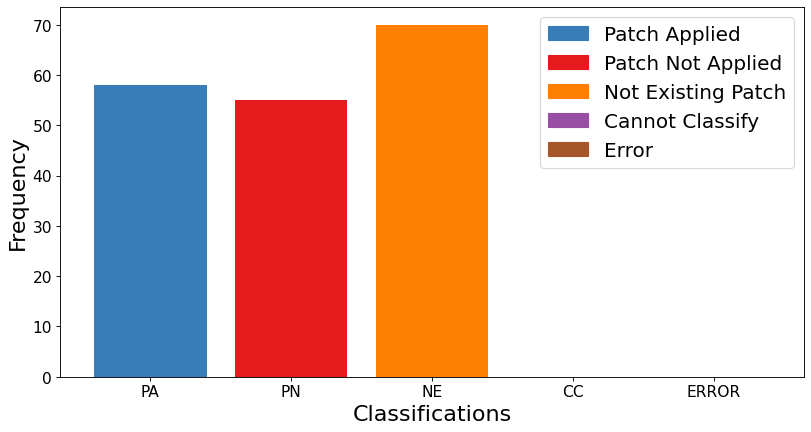

In [31]:
experiment.run_classification(dataDict.pr_project_pair)

In [10]:
#Patches
patch_classes = experiment.df_patch_class()

In [12]:
PA = patch_classes[patch_classes['Patch Classification'] == 'PA']
PA = PA.drop_duplicates()
PA.shape
# PA.to_csv('output_patch_PA.csv')

(58, 6)

In [13]:
NE = patch_classes[patch_classes['Patch Classification'] == 'NE']
NE = NE.drop_duplicates()
NE.shape
# NE.to_csv('output_patch_NE.csv')

(70, 6)

In [14]:
# patch_classes = example.df_patch_class()
PN = patch_classes[patch_classes['Patch Classification'] == 'PN']
PN = PN.drop_duplicates()
PN.shape
# PN.to_csv('output_patch_PN.csv')

(55, 6)

In [20]:
CC = patch_classes[patch_classes['Patch Classification'] == 'CC']
CC = CC.drop_duplicates()
CC.shape

(0, 6)

In [19]:
EE = patch_classes[patch_classes['Patch Classification'] == 'EE']
EE = EE.drop_duplicates()
EE.shape

(0, 6)

In [16]:
#Files
df = experiment.df_file_class()

In [17]:
# df = example.df_file_class()
# df.to_csv('output_patch_classification.csv')

In [27]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Bar(
    x=['PA'],
    y=[PA.shape[0]],
    name="Patch Applied (PA)",
    marker_color='#00A0A0'
))
fig.add_trace(go.Bar(
    x=['PN'],
    y=[PN.shape[0]],
    name="Patch Not Applied (PN)",
    marker_color='#082a54'
))
fig.add_trace(go.Bar(
    x=['NE'],
    y=[NE.shape[0]],
    name="Non-Existent (NE)",
    marker_color='#a00000'
))
fig.add_trace(go.Bar(
    x=['CC'],
    y=[CC.shape[0]],
    name="Cannot Classify",
    marker_color='purple'
))
fig.add_trace(go.Bar(
    x=['EE'],
    y=[EE.shape[0]],
    name="Error (EE)",
    marker_color='#A05000'
))
fig.update_layout(
    xaxis_title="Classifications",
    yaxis_title="Frequency",
    plot_bgcolor= "rgba(0, 0, 0, 0)",
    font_color="black",
    font_size=12,
    height=350,
    width=650,
    bargap=0.45
)
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    # showline=True,
    linecolor='black',
    # gridcolor='lightgrey'
    # orientation='h'
)
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    # showline=True,
    linecolor='black',
    gridcolor='lightgrey',
    # orientation='h'
    # tickangle=330
)
fig.update_layout(
    # autosize=True,
    # try to play around height and width values 
    legend=dict(
    yanchor="top",
    y=0.95,
    xanchor="left",
    x=0.61,
    bordercolor="gray",
    borderwidth=1,
    itemsizing="constant", 
    itemwidth=30,
    font=dict(
            # family="Courier",
            size=12,
        ),
))
fig.show()
# fig.write_image("classification.pdf", width=650, height=350)